# One-shot AFIN Inference

This notebook shows the core AFIN workflow: write a Bayesian model once as a prior plus observed likelihood factors, then swap the first argument to `infer(...)` to compare one-shot AFIN posteriors with exact or NUTS references. The examples are small enough to inspect visually, but they use the same public model API as the README screencast.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "afin").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "demo"))

import importlib

import matplotlib.pyplot as plt
import torch

from figure_style import apply_figure_style
import afin
import afin.api as _afin_api
import afin.inference as _afin_inference
import afin.plotting as _afin_plotting
import afin.spec as _afin_spec

importlib.reload(_afin_spec)
importlib.reload(_afin_inference)
importlib.reload(_afin_api)
importlib.reload(_afin_plotting)
afin = importlib.reload(afin)
from afin import (
    AFIN,
    NumPyroNUTS,
    GaussianPrior,
    LinearGaussian,
    BernoulliLogit,
    LinearStudentT,
    draw_one_shot_panel,
    infer,
    exact_gaussian_regression_posterior,
    make_gaussian_2d_data,
    make_mixed_2d_data,
)

apply_figure_style()
torch.manual_seed(0)

gaussian_afin = AFIN("gaussian")
flow_afin = AFIN("flow")
nuts = NumPyroNUTS(num_warmup=1000, platform="cpu", progress_bar=True)

# Warm up PyTorch/CUDA kernels so the demo timings below report steady-state AFIN forward passes.
_warmup_data = make_gaussian_2d_data(seed=123, n=4, sigma=0.35)
_warmup_prior = GaussianPrior(loc=0, scale=1)
_warmup_observed = [LinearGaussian(design_matrix=_warmup_data["X"], sigma=0.35).observe(_warmup_data["y"])]
_ = infer(gaussian_afin, _warmup_prior, _warmup_observed, seed=0, verbose=False)
_ = infer(flow_afin, _warmup_prior, _warmup_observed, num_samples=16, seed=0, verbose=False)

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

## 1. Gaussian Regression With A Gaussian Decoder

This first example is conjugate Gaussian regression. Because the exact posterior is available in closed form, it is a clean sanity check for the Gaussian-decoder AFIN.

In [2]:
gauss_data = make_gaussian_2d_data(seed=4, n=36, sigma=0.35)

prior = GaussianPrior(loc=0, scale=1)
observed = [
    LinearGaussian(design_matrix=gauss_data["X"], sigma=0.35).observe(gauss_data["y"]),
]

gaussian_post = infer(gaussian_afin, prior, observed, seed=0)
gaussian_reference = exact_gaussian_regression_posterior(gauss_data)

Starting AFIN gaussian...
Finished AFIN gaussian in 0.01 seconds.


## 2. Mixed Likelihoods With A Flow Decoder

The second example combines Gaussian, Bernoulli-logit, and Student-t likelihood factors. There is no conjugate reference, so we compare the flow-decoder AFIN with NumPyro NUTS on the same task declaration.

In [3]:
mixed_data = make_mixed_2d_data(seed=3, n_gaussian=18, n_binary=18, n_student=18)

prior = GaussianPrior(loc=0, scale=1)
observed = [
    LinearGaussian(design_matrix=mixed_data["X_gauss"], sigma=0.35).observe(mixed_data["y_gauss"]),
    BernoulliLogit(design_matrix=mixed_data["X_binary"]).observe(mixed_data["y_binary"]),
    LinearStudentT(design_matrix=mixed_data["X_student"], sigma=0.60, df=4).observe(mixed_data["y_student"]),
]

flow_post = infer(flow_afin, prior, observed, num_samples=3500, seed=0)
flow_reference = infer(nuts, prior, observed, num_samples=6000, seed=0)

Starting AFIN flow...
Finished AFIN flow in 0.03 seconds.
Starting NumPyro NUTS...


sample: 100%|██████████| 7000/7000 [00:02<00:00, 2823.47it/s, 3 steps of size 8.67e-01. acc. prob=0.92]


Finished NumPyro NUTS in 11.7 seconds.


## Summary Figure

Both panels below are drawn by the same helper used by `demo/make_one_shot_figure.py`, which regenerates the static one-shot posterior figure in `demo/assets/`.

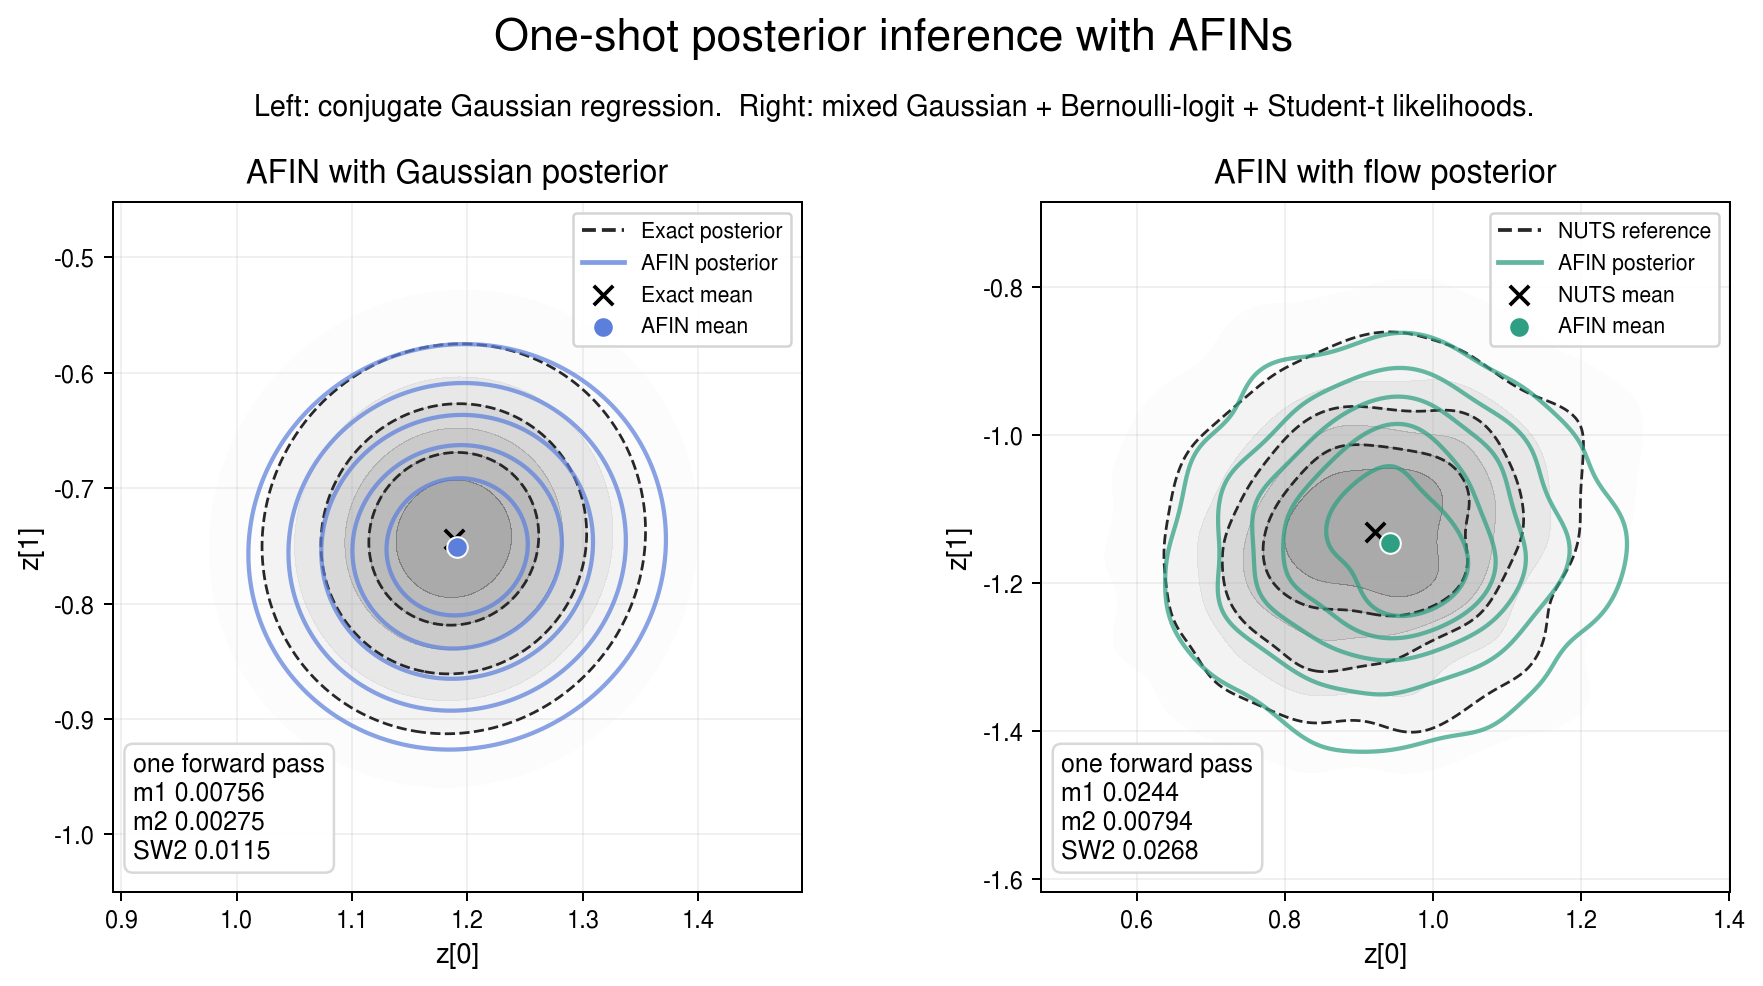

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.55), dpi=180)
fig.subplots_adjust(top=0.80, wspace=0.20)

gaussian_metrics = draw_one_shot_panel(
    axes[0],
    gaussian_post,
    gaussian_reference,
    color="#5B7FDB",
    title="AFIN with Gaussian posterior",
    reference_label="Exact posterior",
    reference_mean_label="Exact mean",
)
flow_metrics = draw_one_shot_panel(
    axes[1],
    flow_post,
    flow_reference,
    color="#2E9F82",
    title="AFIN with flow posterior",
    reference_label="NUTS reference",
    reference_mean_label="NUTS mean",
)

fig.suptitle("One-shot posterior inference with AFINs", fontsize=18, y=0.985)
fig.text(
    0.5,
    0.895,
    "Left: conjugate Gaussian regression.  Right: mixed Gaussian + Bernoulli-logit + Student-t likelihoods.",
    ha="center",
    va="center",
    fontsize=11.5,
)
plt.show()